# Comparative Optimisation of the Travelling Salesman Problem Using Iterated Local Search and Genetic Algorithms

## Research question

How effectively do Iterated Local Search and Genetic Algorithms solve the Travelling Salesman Problem as problem size increases from 10 to 50 cities, considering solution quality, convergence, computational efficiency and robustness?

## Experimental design

- Dataset: `cities.csv`
- Problem sizes: 10, 20, 30, 40 and 50 cities
- Algorithms: Iterated Local Search and Genetic Algorithm
- Independent runs: 10 per algorithm per problem size
- Seeds: 42–51
- Distance measure: Euclidean distance

## Background and Problem Definition

The Travelling Salesman Problem (TSP) seeks the shortest closed route that visits every city exactly once and returns to its starting point. This project considers a symmetric Euclidean TSP: cities are represented by two-dimensional coordinates, and travel costs are straight-line distances. The closed-tour formulation is described in the TSP literature, including Croes (1958). [Source](https://pubsonline.informs.org/doi/10.1287/opre.6.6.791)

For cities \(i\) and \(j\), the distance is:

$$
d(i,j)=\sqrt{(x_i-x_j)^2+(y_i-y_j)^2}
$$

For a visiting order \(\pi\), the objective is to minimise:

$$
L(\pi)=\sum_{k=0}^{n-2}d(\pi_k,\pi_{k+1})
+d(\pi_{n-1},\pi_0)
$$

A valid route contains every selected city exactly once. The final term accounts for returning to the starting city. Distances are reported in coordinate units because the dataset does not specify a physical unit.

This project compares two search approaches: Iterated Local Search and a Genetic Algorithm. Their performance is assessed through final route quality, convergence, runtime, and variation across repeated seeded runs.


## Algorithm Selection and Justification

Iterated Local Search repeatedly perturbs a solution and applies an embedded local search to explore alternative local optima. Its framework separates the initial solution, local search, perturbation, and acceptance rule, making these design choices explicit (Lourenço, Martin and Stützle, 2001). [Source](https://arxiv.org/abs/math/0102188)

In this implementation, ILS starts from a random permutation and applies first-improvement 2-opt. Perturbation swaps two disjoint pairs of cities while preserving the starting position. The perturbed route undergoes another local search, and it replaces the incumbent only if it is shorter. Search stops when the evaluation budget is exhausted, which may interrupt a local search before a local optimum is reached.

Genetic Algorithms provide an evolutionary approach to search, with candidate information passed between generations through selection and recombination. Holland’s work provides a foundational account of this approach (Holland, 1992). [Source](https://mitpress.mit.edu/9780262581110/adaptation-in-natural-and-artificial-systems/)

The GA implemented here maintains 50 routes. Tournament selection chooses parents, order crossover constructs valid offspring, and inversion mutation introduces variation. One elite route is preserved between generations. Mutation has a probability of 0.2 per offspring, and each tournament contains three individuals.

These algorithms were selected to compare two different search strategies: improving and perturbing an incumbent route, and evolving a population through selection and recombination. Their relative performance is investigated experimentally rather than assumed in advance.


### Rationale for the search operators

**2-opt local search.** Reversing a segment in a symmetric TSP preserves its internal undirected edges while changing the two boundary connections. This allows 2-opt to replace expensive connections and remove crossings in Euclidean tours. The implementation accepts the first distance-reducing move encountered and restarts the search.

**ILS perturbation.** Two disjoint pairs of cities are swapped while preserving the starting position and maintaining a valid route. This changes the starting arrangement for another local search. The operator is a two-swap perturbation, not a double-bridge move. Local search may return to the same local optimum, so improvement is not guaranteed.

**GA crossover and mutation.** Order crossover preserves a consecutive segment from one parent and fills the remaining positions using the other parent’s circular order, preventing duplicated or missing cities. However, useful parent edges may be lost. Inversion mutation reverses a route segment without requiring an immediate improvement, introducing variation into the population.

**Selection and elitism.** Tournament selection favours shorter routes while allowing different individuals to become parents. Preserving one elite route ensures that the best solution found is retained between generations.

These properties explain the choice of operators. They do not establish that two swaps outperform one swap, or that inversion outperforms swap mutation. Such conclusions would require controlled operator-comparison experiments.

## Experimental Methodology

The dataset contains 50 cities with identifier, X-coordinate, and Y-coordinate columns. Five instances were constructed using the first 10, 20, 30, 40, and 50 rows in their original order. Both algorithms received identical coordinates and distance matrices for each instance.

A pilot used the 50-city instance and seeds 142–144 to inspect progress at 10,000, 50,000, and 100,000 evaluations. Increasing the budget from 50,000 to 100,000 reduced ILS’s mean distance from 613.42 to 577.17, an improvement of approximately 5.91%. GA’s mean distance remained 597.63 at the displayed precision over the same interval.

The initial 2-opt searches required 55,118, 45,118, and 59,559 evaluations for seeds 142, 143, and 144 respectively. A budget of 50,000 would therefore interrupt the initial local search in two of the three ILS runs. At 100,000 evaluations, all three runs had budget available for perturbation and further local search.

A common budget of 100,000 evaluations was selected for the main experiment. This was a practical choice supported by the pilot, not a guarantee that either algorithm had fully converged.

The main experiment used seeds 42–51 for each algorithm and instance, producing 100 runs. Algorithm execution order was alternated. Reusing the seeds introduced shared initial randomness between algorithms, which was acknowledged in the statistical analysis.

One evaluation was defined as a complete route-distance calculation. Initial solutions and rejected candidates counted toward the budget. GA reused the elite route’s previously calculated distance. Both algorithms stopped exactly at the evaluation limit. The minimum and maximum evaluation counts were both 100,000 for every algorithm–instance combination.

Runtime was measured using `time.perf_counter()`. It included algorithm initialisation, search operations, and convergence-history recording. Distance-matrix construction, result validation, plotting, and file saving were excluded.

Each run recorded its best distance, runtime, evaluation count, final route, and convergence history. Descriptive statistics included the minimum, maximum, mean, median, and sample standard deviation. Convergence histories were aligned at common evaluation counts before averaging.

Final distances were compared separately at each problem size using two-sided Welch and Mann–Whitney tests, alongside an exact paired permutation sensitivity check. Holm correction was applied across 15 planned comparisons at a significance threshold of 0.05. Distances were rounded to nine decimal places for these tests only to remove negligible floating-point differences. The independent-sample tests were treated as exploratory because seeds were reused across algorithms.


In [1]:
import random
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

SEEDS = list(range(42, 52))
PROBLEM_SIZES = [10, 20, 30, 40, 50]

print("Seeds:", SEEDS)
print("Problem sizes:", PROBLEM_SIZES)

C:\Users\yasee\AppData\Local\Temp\ipykernel_26372\1903768568.py:8: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy import stats


Seeds: [42, 43, 44, 45, 46, 47, 48, 49, 50, 51]
Problem sizes: [10, 20, 30, 40, 50]


In [8]:
import pandas as pd

cities_df = pd.read_csv("Dataset/cities.csv")

print("Dataset shape:", cities_df.shape)
cities_df.head()

Dataset shape: (50, 3)


,City,X,Y
0,City_1,37.454012,95.071431
1,City_2,73.199394,59.865848
2,City_3,15.601864,15.599452
3,City_4,5.808361,86.617615
4,City_5,60.111501,70.807258


In [9]:
required_columns = {"City", "X", "Y"}

assert required_columns.issubset(cities_df.columns), (
    f"Missing columns: {required_columns - set(cities_df.columns)}"
)

assert len(cities_df) >= max(PROBLEM_SIZES), (
    "The dataset does not contain enough cities."
)

assert not cities_df[["City", "X", "Y"]].isnull().any().any(), (
    "The dataset contains missing values."
)

assert not cities_df["City"].duplicated().any(), (
    "The dataset contains duplicate city names."
)

assert not cities_df[["X", "Y"]].duplicated().any(), (
    "The dataset contains duplicate coordinates."
)

print("Dataset validation passed.")
print(f"Number of cities: {len(cities_df)}")
print(f"X range: {cities_df['X'].min():.2f} to {cities_df['X'].max():.2f}")
print(f"Y range: {cities_df['Y'].min():.2f} to {cities_df['Y'].max():.2f}")

Dataset validation passed.
Number of cities: 50
X range: 0.55 to 96.96
Y range: 4.65 to 98.69


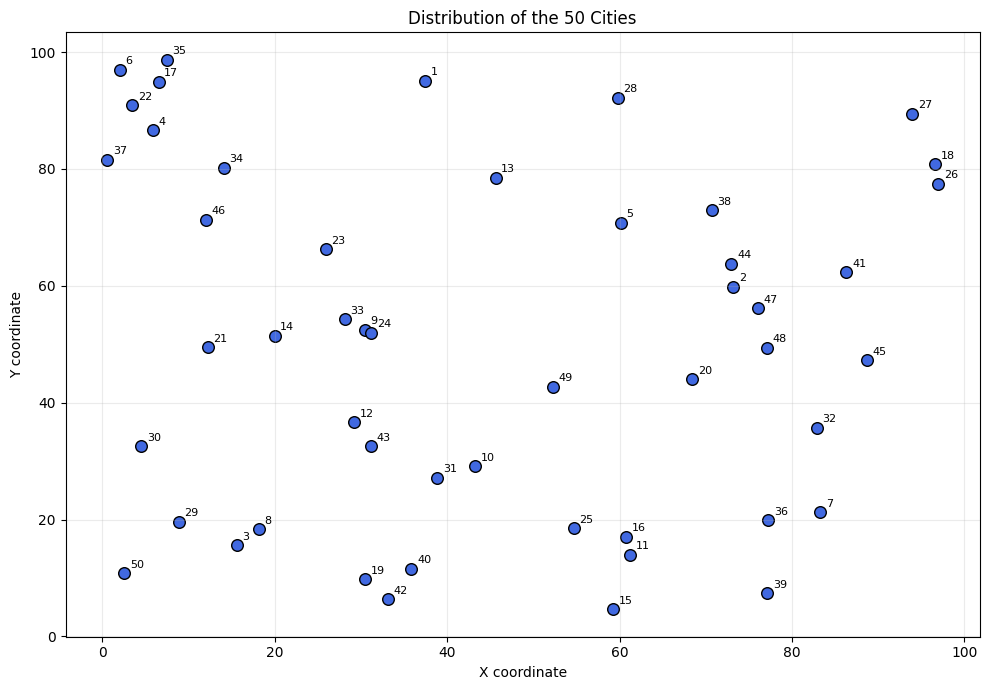

In [10]:
plt.figure(figsize=(10, 7))

plt.scatter(
    cities_df["X"],
    cities_df["Y"],
    color="royalblue",
    edgecolor="black",
    s=70
)

for _, city in cities_df.iterrows():
    plt.annotate(
        city["City"].replace("City_", ""),
        (city["X"], city["Y"]),
        xytext=(4, 4),
        textcoords="offset points",
        fontsize=8
    )

plt.title("Distribution of the 50 Cities")
plt.xlabel("X coordinate")
plt.ylabel("Y coordinate")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [11]:
city_names = cities_df["City"].to_numpy()
coordinates = cities_df[["X", "Y"]].to_numpy(dtype=float)

print("City names shape:", city_names.shape)
print("Coordinates shape:", coordinates.shape)
print("First city:", city_names[0], coordinates[0])

City names shape: (50,)
Coordinates shape: (50, 2)
First city: City_1 [37.45401188 95.07143064]


In [12]:
def create_distance_matrix(coords):
    number_of_cities = len(coords)
    matrix = np.zeros((number_of_cities, number_of_cities))

    for i in range(number_of_cities):
        for j in range(i + 1, number_of_cities):
            difference = coords[i] - coords[j]
            distance = np.sqrt(np.sum(difference ** 2))

            matrix[i, j] = distance
            matrix[j, i] = distance

    return matrix


distance_matrix = create_distance_matrix(coordinates)

print("Distance matrix shape:", distance_matrix.shape)

pd.DataFrame(
    distance_matrix,
    index=city_names,
    columns=city_names
).iloc[:5, :5]

Distance matrix shape: (50, 50)


,City_1,City_2,City_3,City_4,City_5
City_1,0.000000,50.171360,82.421549,32.755369,33.198071
City_2,50.171360,0.000000,72.642889,72.506609,17.058938
City_3,82.421549,72.642889,0.000000,71.690251,70.915510
City_4,32.755369,72.506609,71.690251,0.000000,56.557921
City_5,33.198071,17.058938,70.915510,56.557921,0.000000


In [13]:
def calculate_route_distance(route, matrix):
    total_distance = 0.0
    number_of_cities = len(route)

    for i in range(number_of_cities):
        current_city = route[i]
        next_city = route[(i + 1) % number_of_cities]

        total_distance += matrix[current_city, next_city]

    return float(total_distance)

In [14]:
square_coordinates = np.array([
    [0, 0],
    [1, 0],
    [1, 1],
    [0, 1]
], dtype=float)

square_matrix = create_distance_matrix(square_coordinates)
square_route = [0, 1, 2, 3]

square_distance = calculate_route_distance(
    square_route,
    square_matrix
)

assert np.isclose(square_distance, 4.0)
assert np.isclose(square_matrix[0, 2], np.sqrt(2))
assert np.allclose(distance_matrix, distance_matrix.T)
assert np.allclose(np.diag(distance_matrix), 0)

print("Square route distance:", square_distance)
print("All distance checks passed.")

Square route distance: 4.0
All distance checks passed.


In [15]:
number_of_cities = 10

# Both algorithms will use the same first n cities for each problem size.
small_matrix = distance_matrix[:number_of_cities, :number_of_cities]

# Visit cities in their original dataset order.
initial_route = list(range(number_of_cities))

assert sorted(initial_route) == list(range(number_of_cities))

initial_distance = calculate_route_distance(
    initial_route,
    small_matrix
)

route_labels = [city_names[i] for i in initial_route]
route_labels.append(route_labels[0])

print("Route:", " → ".join(route_labels))
print(f"Total distance: {initial_distance:.2f}")

Route: City_1 → City_2 → City_3 → City_4 → City_5 → City_6 → City_7 → City_8 → City_9 → City_10 → City_1
Total distance: 619.99


In [16]:
def generate_random_route(number_of_cities, seed):
    rng = np.random.default_rng(seed)
    return rng.permutation(number_of_cities).tolist()


random_route = generate_random_route(
    number_of_cities=10,
    seed=42
)

random_distance = calculate_route_distance(
    random_route,
    small_matrix
)

assert sorted(random_route) == list(range(10))

print("Route indices:", random_route)
print(f"Random route distance: {random_distance:.2f}")
print(f"Dataset-order route distance: {initial_distance:.2f}")

Route indices: [5, 6, 0, 7, 3, 2, 4, 9, 1, 8]
Random route distance: 673.17
Dataset-order route distance: 619.99


In [17]:
def plot_route(route, coords, names, matrix, title):
    # Repeat the starting city to draw the return journey.
    closed_route = route + [route[0]]
    route_coordinates = coords[closed_route]

    distance = calculate_route_distance(route, matrix)

    fig, ax = plt.subplots(figsize=(9, 7))

    ax.plot(
        route_coordinates[:, 0],
        route_coordinates[:, 1],
        color="royalblue",
        linewidth=1.5,
        zorder=1
    )

    ax.scatter(
        coords[route, 0],
        coords[route, 1],
        color="royalblue",
        edgecolor="black",
        s=80,
        zorder=2
    )

    for city_index in route:
        ax.annotate(
            names[city_index],
            coords[city_index],
            xytext=(6, 6),
            textcoords="offset points",
            fontsize=9
        )

    start = route[0]

    ax.scatter(
        coords[start, 0],
        coords[start, 1],
        color="orange",
        edgecolor="black",
        marker="*",
        s=280,
        label="Start / finish",
        zorder=3
    )

    ax.set_title(f"{title}\nTotal distance: {distance:.2f}")
    ax.set_xlabel("X coordinate")
    ax.set_ylabel("Y coordinate")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.25)
    ax.legend()

    plt.tight_layout()
    plt.show()

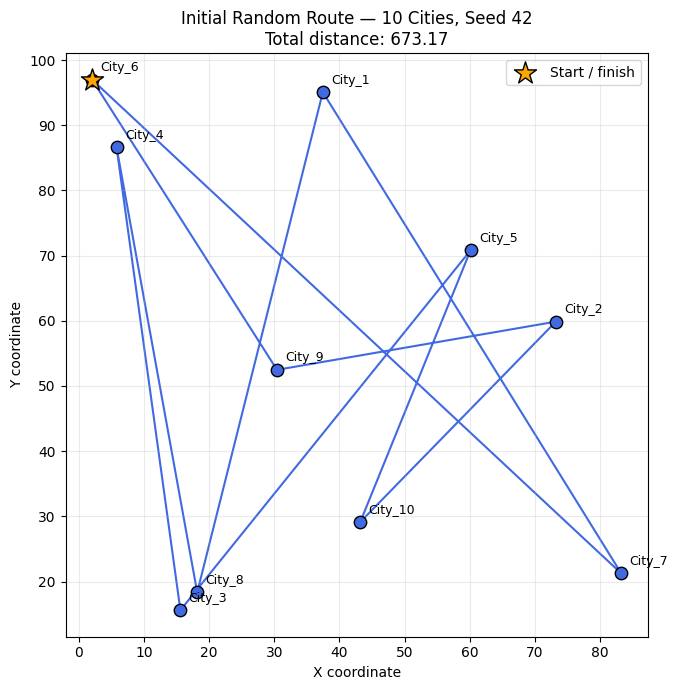

In [18]:
plot_route(
    route=random_route,
    coords=coordinates[:10],
    names=city_names[:10],
    matrix=small_matrix,
    title="Initial Random Route — 10 Cities, Seed 42"
)

In [19]:
repeated_route = generate_random_route(10, seed=42)

assert random_route == repeated_route

print("Reproducibility check passed.")

Reproducibility check passed.


In [42]:
def two_opt_local_search(route, matrix, max_evaluations=None):
    if max_evaluations is not None and max_evaluations < 1:
        raise ValueError("The budget must allow at least one evaluation.")

    best_route = list(route)
    best_distance = calculate_route_distance(best_route, matrix)

    evaluations = 1
    history = [(evaluations, best_distance)]
    n = len(best_route)

    while True:
        improved = False

        for i in range(1, n - 1):
            for j in range(i + 1, n):
                if i == 1 and j == n - 1:
                    continue

                # Stop before another distance calculation.
                if (
                    max_evaluations is not None
                    and evaluations >= max_evaluations
                ):
                    history.append((evaluations, best_distance))
                    return (
                        best_route, best_distance,
                        evaluations, history
                    )

                candidate = (
                    best_route[:i]
                    + best_route[i:j + 1][::-1]
                    + best_route[j + 1:]
                )

                candidate_distance = calculate_route_distance(
                    candidate, matrix
                )
                evaluations += 1

                if candidate_distance < best_distance - 1e-12:
                    best_route = candidate
                    best_distance = candidate_distance
                    history.append((evaluations, best_distance))

                    improved = True
                    break

            if improved:
                break

        if not improved:
            break

    history.append((evaluations, best_distance))

    return best_route, best_distance, evaluations, history

In [21]:
start_time = time.perf_counter()

(
    local_route,
    local_distance,
    local_evaluations,
    local_history
) = two_opt_local_search(random_route, small_matrix)

local_runtime = time.perf_counter() - start_time

improvement_percent = (
    (random_distance - local_distance) / random_distance
) * 100

assert sorted(local_route) == list(range(10))
assert local_distance <= random_distance
assert np.isclose(
    local_distance,
    calculate_route_distance(local_route, small_matrix)
)

print(f"Initial distance: {random_distance:.2f}")
print(f"After 2-opt: {local_distance:.2f}")
print(f"Improvement: {improvement_percent:.2f}%")
print(f"Route evaluations: {local_evaluations}")
print(f"Runtime: {local_runtime:.6f} seconds")
print("Improved route indices:", local_route)

Initial distance: 673.17
After 2-opt: 290.31
Improvement: 56.87%
Route evaluations: 202
Runtime: 0.001766 seconds
Improved route indices: [5, 3, 8, 2, 7, 9, 6, 1, 4, 0]


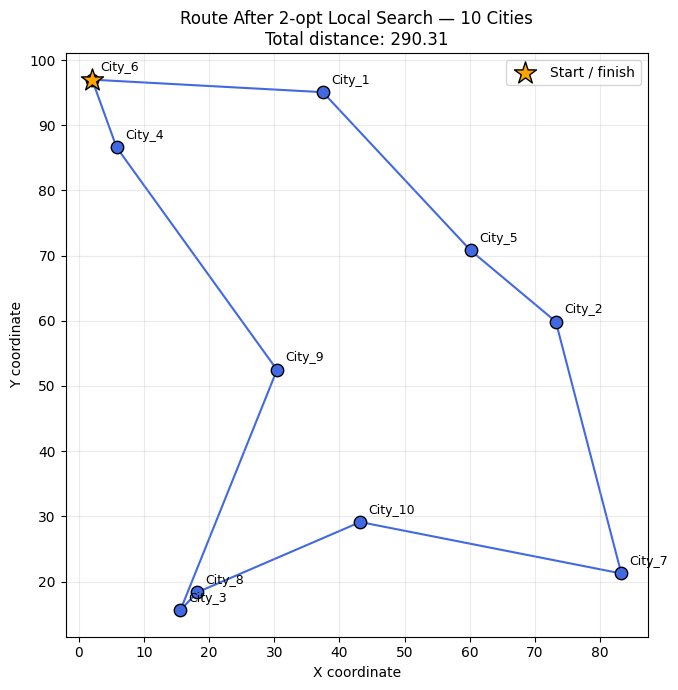

In [22]:
plot_route(
    route=local_route,
    coords=coordinates[:10],
    names=city_names[:10],
    matrix=small_matrix,
    title="Route After 2-opt Local Search — 10 Cities"
)

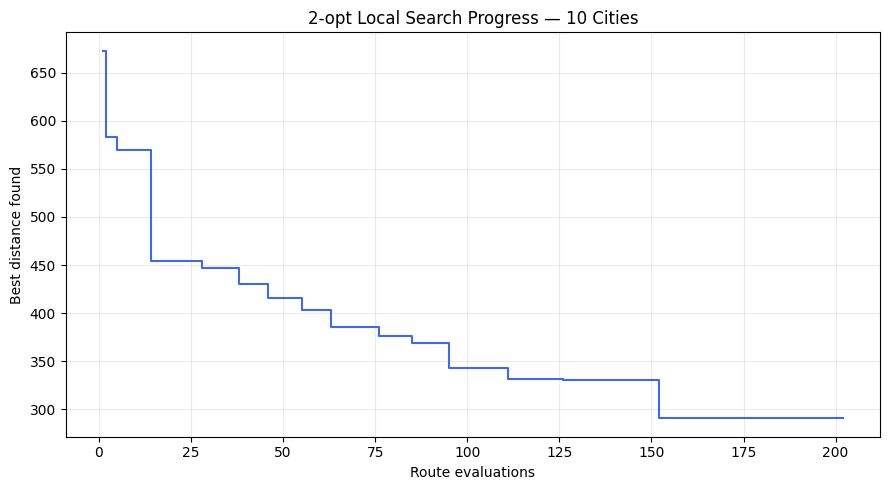

In [23]:
evaluation_counts, distances = zip(*local_history)

plt.figure(figsize=(9, 5))

plt.step(
    evaluation_counts,
    distances,
    where="post",
    color="royalblue"
)

plt.title("2-opt Local Search Progress — 10 Cities")
plt.xlabel("Route evaluations")
plt.ylabel("Best distance found")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [24]:
def perturb_route(route, rng):
    if len(route) < 5:
        raise ValueError("This perturbation requires at least 5 cities.")

    perturbed = list(route)

    # Choose four different positions, keeping the starting city fixed.
    a, b, c, d = rng.choice(
        np.arange(1, len(route)),
        size=4,
        replace=False
    )

    # Swap two separate pairs.
    perturbed[a], perturbed[b] = perturbed[b], perturbed[a]
    perturbed[c], perturbed[d] = perturbed[d], perturbed[c]

    return perturbed

In [25]:
def iterated_local_search(matrix, seed, iterations=50):
    if len(matrix) < 5:
        raise ValueError("ILS requires at least 5 cities.")

    if iterations < 0:
        raise ValueError("Iterations must be non-negative.")

    rng = np.random.default_rng(seed)

    starting_route = rng.permutation(len(matrix)).tolist()

    # Initial local search.
    (
        best_route,
        best_distance,
        evaluations,
        history
    ) = two_opt_local_search(starting_route, matrix)

    for _ in range(iterations):
        perturbed = perturb_route(best_route, rng)

        (
            candidate_route,
            candidate_distance,
            used,
            candidate_history
        ) = two_opt_local_search(perturbed, matrix)

        # Convert local evaluation counts into cumulative ILS counts.
        # Record the best distance found across the entire run.
        for local_count, local_distance in candidate_history:
            history.append((
                evaluations + local_count,
                min(best_distance, local_distance)
            ))

        evaluations += used

        # Accept only improvements to the incumbent route.
        if candidate_distance < best_distance - 1e-12:
            best_route = candidate_route
            best_distance = candidate_distance

    return {
        "route": best_route,
        "distance": best_distance,
        "evaluations": evaluations,
        "history": history
    }

In [26]:
start_time = time.perf_counter()

ils_result = iterated_local_search(
    matrix=small_matrix,
    seed=42,
    iterations=50
)

ils_runtime = time.perf_counter() - start_time

assert sorted(ils_result["route"]) == list(range(10))

assert np.isclose(
    ils_result["distance"],
    calculate_route_distance(ils_result["route"], small_matrix)
)

# The same seed gives the same initial route as our earlier example.
assert ils_result["distance"] <= local_distance + 1e-12

print(f"Random route: {random_distance:.2f}")
print(f"Single 2-opt search: {local_distance:.2f}")
print(f"ILS best distance: {ils_result['distance']:.2f}")
print(f"ILS evaluations: {ils_result['evaluations']}")
print(f"ILS runtime: {ils_runtime:.6f} seconds")

Random route: 673.17
Single 2-opt search: 290.31
ILS best distance: 290.31
ILS evaluations: 5903
ILS runtime: 0.090939 seconds


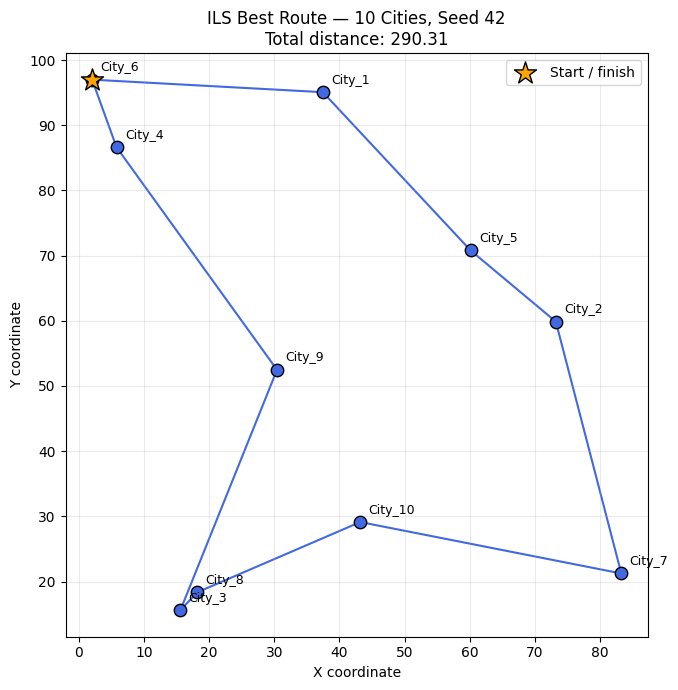

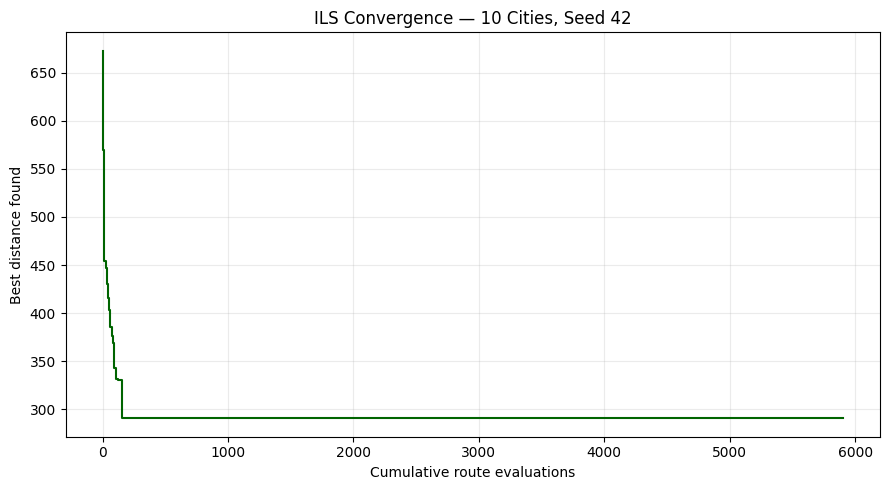

In [27]:
plot_route(
    route=ils_result["route"],
    coords=coordinates[:10],
    names=city_names[:10],
    matrix=small_matrix,
    title="ILS Best Route — 10 Cities, Seed 42"
)

evaluation_counts, best_distances = zip(*ils_result["history"])

plt.figure(figsize=(9, 5))

plt.step(
    evaluation_counts,
    best_distances,
    where="post",
    color="darkgreen"
)

plt.title("ILS Convergence — 10 Cities, Seed 42")
plt.xlabel("Cumulative route evaluations")
plt.ylabel("Best distance found")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [28]:
ils_repeat = iterated_local_search(
    matrix=small_matrix,
    seed=42,
    iterations=50
)

assert ils_result == ils_repeat

print("ILS reproducibility check passed.")

ILS reproducibility check passed.


Start the Genetic Algorithm—population, evaluation, and parent selection.

In [29]:
def create_population(number_of_cities, population_size, rng):
    population = []

    for _ in range(population_size):
        route = rng.permutation(number_of_cities).tolist()
        population.append(route)

    return population

In [30]:
def evaluate_population(population, matrix):
    distances = np.array([
        calculate_route_distance(route, matrix)
        for route in population
    ])

    evaluations = len(population)

    return distances, evaluations

In [31]:
ga_rng = np.random.default_rng(42)

population = create_population(
    number_of_cities=10,
    population_size=50,
    rng=ga_rng
)

population_distances, population_evaluations = evaluate_population(
    population,
    small_matrix
)

# Every individual must be a valid route.
assert len(population) == 50
assert all(
    sorted(route) == list(range(10))
    for route in population
)

best_index = int(np.argmin(population_distances))

print("Population size:", len(population))
print("Evaluations:", population_evaluations)
print(f"Best initial distance: {population_distances.min():.2f}")
print(f"Mean initial distance: {population_distances.mean():.2f}")
print(f"Worst initial distance: {population_distances.max():.2f}")
print("Best initial route:", population[best_index])

pd.DataFrame({
    "Individual": np.arange(1, len(population) + 1),
    "Distance": population_distances
}).head(10)

Population size: 50
Evaluations: 50
Best initial distance: 420.12
Mean initial distance: 558.40
Worst initial distance: 689.78
Best initial route: [0, 5, 8, 1, 2, 7, 9, 6, 4, 3]


,Individual,Distance
0,1,673.172739
1,2,529.526785
2,3,482.482658
3,4,477.899588
4,5,624.121628
5,6,420.123614
6,7,526.049424
7,8,578.435265
8,9,562.980056
9,10,558.414785


In [32]:
def tournament_selection(
    population,
    distances,
    rng,
    tournament_size=3
):
    if not 1 <= tournament_size <= len(population):
        raise ValueError(
            "Tournament size must be between 1 and the population size."
        )

    candidate_indices = rng.choice(
        len(population),
        size=tournament_size,
        replace=False
    )

    winner_index = min(
        candidate_indices,
        key=lambda index: distances[index]
    )

    return list(population[winner_index])

In [33]:
parent_1 = tournament_selection(
    population,
    population_distances,
    ga_rng
)

parent_2 = tournament_selection(
    population,
    population_distances,
    ga_rng
)

assert sorted(parent_1) == list(range(10))
assert sorted(parent_2) == list(range(10))

print("Parent 1:", parent_1)
print("Parent 2:", parent_2)

Parent 1: [6, 7, 8, 4, 2, 0, 3, 5, 9, 1]
Parent 2: [2, 6, 3, 9, 4, 1, 8, 7, 5, 0]


In [34]:
def order_crossover(parent_1, parent_2, rng):
    n = len(parent_1)

    # Choose the boundaries of the inherited section.
    start, end = sorted(
        rng.choice(n, size=2, replace=False)
    )

    child = [None] * n

    # Copy Parent 1's section, including both boundaries.
    child[start:end + 1] = parent_1[start:end + 1]

    inherited_cities = set(parent_1[start:end + 1])

    # Read Parent 2 from after the section, wrapping around.
    donor_order = (
        parent_2[end + 1:]
        + parent_2[:end + 1]
    )

    remaining_cities = [
        city for city in donor_order
        if city not in inherited_cities
    ]

    # Fill empty positions in the same circular order.
    empty_positions = (
        list(range(end + 1, n))
        + list(range(0, start))
    )

    for position, city in zip(empty_positions, remaining_cities):
        child[position] = city

    return child

In [35]:
# Use a separate generator for this demonstration.
operator_rng = np.random.default_rng(42)

parent_1_before = parent_1.copy()
parent_2_before = parent_2.copy()

child = order_crossover(
    parent_1,
    parent_2,
    operator_rng
)

assert sorted(child) == list(range(10))
assert parent_1 == parent_1_before
assert parent_2 == parent_2_before

print("Parent 1:", parent_1)
print("Parent 2:", parent_2)
print("Child:   ", child)
print("Crossover validity checks passed.")

Parent 1: [6, 7, 8, 4, 2, 0, 3, 5, 9, 1]
Parent 2: [2, 6, 3, 9, 4, 1, 8, 7, 5, 0]
Child:    [6, 7, 8, 4, 2, 0, 3, 5, 9, 1]
Crossover validity checks passed.


In [36]:
def inversion_mutation(route, rng, mutation_rate=0.2):
    if not 0 <= mutation_rate <= 1:
        raise ValueError("Mutation rate must be between 0 and 1.")

    mutated = list(route)

    if rng.random() < mutation_rate:
        start, end = sorted(
            rng.choice(len(mutated), size=2, replace=False)
        )

        mutated[start:end + 1] = (
            mutated[start:end + 1][::-1]
        )

    return mutated

In [37]:
child_before = child.copy()

mutated_child = inversion_mutation(
    child,
    operator_rng,
    mutation_rate=1.0
)

assert sorted(mutated_child) == list(range(10))
assert child == child_before
assert mutated_child != child

print("Before mutation:", child)
print("After mutation: ", mutated_child)
print("Mutation validity checks passed.")

Before mutation: [6, 7, 8, 4, 2, 0, 3, 5, 9, 1]
After mutation:  [4, 8, 7, 6, 2, 0, 3, 5, 9, 1]
Mutation validity checks passed.


In [38]:
def genetic_algorithm(
    matrix,
    seed,
    population_size=50,
    max_evaluations=5000,
    mutation_rate=0.2,
    tournament_size=3
):
    if len(matrix) < 2:
        raise ValueError("At least 2 cities are required.")

    if population_size < 2:
        raise ValueError("Population size must be at least 2.")

    if max_evaluations < population_size:
        raise ValueError("The budget must cover the initial population.")

    if not 1 <= tournament_size <= population_size:
        raise ValueError("Invalid tournament size.")

    if not 0 <= mutation_rate <= 1:
        raise ValueError("Mutation rate must be between 0 and 1.")

    rng = np.random.default_rng(seed)

    population = create_population(
        len(matrix), population_size, rng
    )

    distances, evaluations = evaluate_population(
        population, matrix
    )

    best_index = int(np.argmin(distances))
    best_route = population[best_index].copy()
    best_distance = float(distances[best_index])

    # Best distance after each initial population evaluation.
    history = [
        (i + 1, float(distance))
        for i, distance in enumerate(np.minimum.accumulate(distances))
    ]

    while evaluations < max_evaluations:
        # Elitism: preserve the best route and its known distance.
        next_population = [best_route.copy()]
        next_distances = [best_distance]

        while (
            len(next_population) < population_size
            and evaluations < max_evaluations
        ):
            parent_1 = tournament_selection(
                population, distances, rng, tournament_size
            )
            parent_2 = tournament_selection(
                population, distances, rng, tournament_size
            )

            child = order_crossover(parent_1, parent_2, rng)
            child = inversion_mutation(child, rng, mutation_rate)

            child_distance = calculate_route_distance(child, matrix)
            evaluations += 1

            next_population.append(child)
            next_distances.append(child_distance)

            if child_distance < best_distance:
                best_route = child.copy()
                best_distance = child_distance

            history.append((evaluations, best_distance))

        population = next_population
        distances = np.array(next_distances)

    return {
        "route": best_route,
        "distance": best_distance,
        "evaluations": evaluations,
        "history": history
    }

In [39]:
start_time = time.perf_counter()

ga_result = genetic_algorithm(
    matrix=small_matrix,
    seed=42,
    population_size=50,
    max_evaluations=5000,
    mutation_rate=0.2,
    tournament_size=3
)

ga_runtime = time.perf_counter() - start_time

assert sorted(ga_result["route"]) == list(range(10))
assert ga_result["evaluations"] == 5000

assert np.isclose(
    ga_result["distance"],
    calculate_route_distance(ga_result["route"], small_matrix)
)

print(f"GA best distance: {ga_result['distance']:.2f}")
print(f"GA evaluations: {ga_result['evaluations']}")
print(f"GA runtime: {ga_runtime:.6f} seconds")
print("GA best route:", ga_result["route"])

GA best distance: 290.31
GA evaluations: 5000
GA runtime: 0.313227 seconds
GA best route: [0, 4, 1, 6, 9, 7, 2, 8, 3, 5]


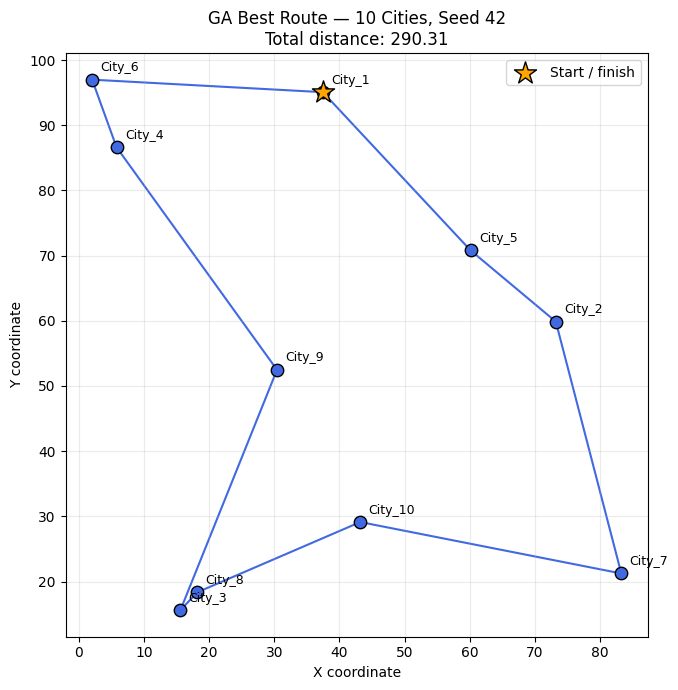

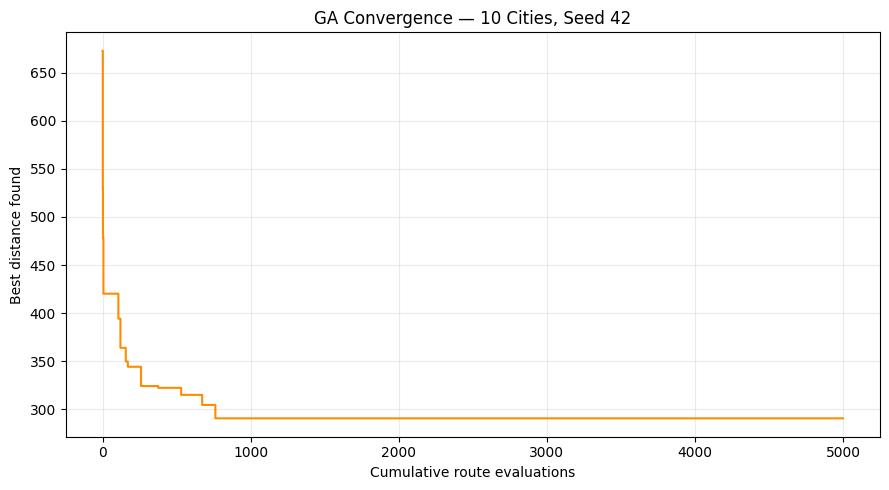

In [40]:
plot_route(
    route=ga_result["route"],
    coords=coordinates[:10],
    names=city_names[:10],
    matrix=small_matrix,
    title="GA Best Route — 10 Cities, Seed 42"
)

evaluation_counts, best_distances = zip(*ga_result["history"])

plt.figure(figsize=(9, 5))

plt.step(
    evaluation_counts,
    best_distances,
    where="post",
    color="darkorange"
)

plt.title("GA Convergence — 10 Cities, Seed 42")
plt.xlabel("Cumulative route evaluations")
plt.ylabel("Best distance found")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

In [41]:
ga_repeat = genetic_algorithm(
    matrix=small_matrix,
    seed=42,
    population_size=50,
    max_evaluations=5000,
    mutation_rate=0.2,
    tournament_size=3
)

assert ga_result == ga_repeat

history_distances = np.array([
    distance for _, distance in ga_result["history"]
])

assert np.all(np.diff(history_distances) <= 0)

assert ga_result["history"][-1][0] == ga_result["evaluations"]

print("GA reproducibility and convergence checks passed.")

GA reproducibility and convergence checks passed.


In [43]:
def iterated_local_search_budgeted(
    matrix,
    seed,
    max_evaluations=5000
):
    if len(matrix) < 5:
        raise ValueError("ILS requires at least 5 cities.")

    if max_evaluations < 1:
        raise ValueError("The budget must be positive.")

    rng = np.random.default_rng(seed)
    starting_route = rng.permutation(len(matrix)).tolist()

    (
        best_route,
        best_distance,
        evaluations,
        history
    ) = two_opt_local_search(
        starting_route,
        matrix,
        max_evaluations=max_evaluations
    )

    while evaluations < max_evaluations:
        perturbed = perturb_route(best_route, rng)
        remaining = max_evaluations - evaluations

        (
            candidate_route,
            candidate_distance,
            used,
            candidate_history
        ) = two_opt_local_search(
            perturbed,
            matrix,
            max_evaluations=remaining
        )

        for local_count, local_distance in candidate_history:
            history.append((
                evaluations + local_count,
                min(best_distance, local_distance)
            ))

        evaluations += used

        if candidate_distance < best_distance - 1e-12:
            best_route = candidate_route
            best_distance = candidate_distance

    return {
        "route": best_route,
        "distance": best_distance,
        "evaluations": evaluations,
        "history": history
    }

In [44]:
DEMO_BUDGET = 5000

algorithms = {
    "ILS": iterated_local_search_budgeted,
    "GA": genetic_algorithm
}

demo_results = {}
comparison_rows = []

for name, algorithm in algorithms.items():
    start_time = time.perf_counter()

    result = algorithm(
        matrix=small_matrix,
        seed=42,
        max_evaluations=DEMO_BUDGET
    )

    runtime = time.perf_counter() - start_time

    assert result["evaluations"] == DEMO_BUDGET
    assert sorted(result["route"]) == list(range(10))

    assert np.isclose(
        result["distance"],
        calculate_route_distance(result["route"], small_matrix)
    )

    demo_results[name] = result

    comparison_rows.append({
        "Algorithm": name,
        "City count": 10,
        "Seed": 42,
        "Best distance": result["distance"],
        "Evaluations": result["evaluations"],
        "Runtime (seconds)": runtime
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df

,Algorithm,City count,Seed,Best distance,Evaluations,Runtime (seconds)
0,ILS,10,42,290.306774,5000,0.047520
1,GA,10,42,290.306774,5000,0.540158


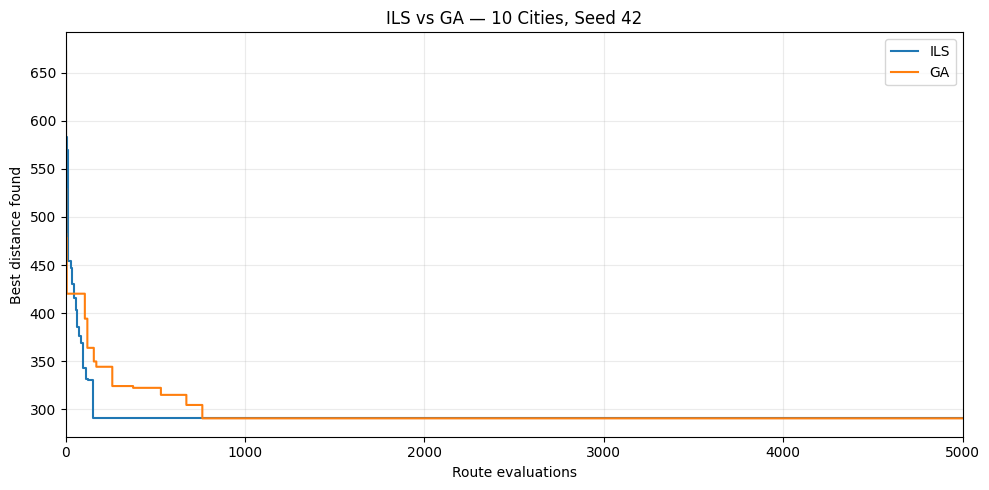

In [45]:
plt.figure(figsize=(10, 5))

for name, result in demo_results.items():
    counts, distances = zip(*result["history"])

    plt.step(
        counts,
        distances,
        where="post",
        label=name
    )

plt.title("ILS vs GA — 10 Cities, Seed 42")
plt.xlabel("Route evaluations")
plt.ylabel("Best distance found")
plt.xlim(0, DEMO_BUDGET)
plt.grid(alpha=0.25)
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
PILOT_SEEDS = [142, 143, 144]
PILOT_CHECKPOINTS = [10_000, 50_000, 100_000]
PILOT_MAX_EVALUATIONS = max(PILOT_CHECKPOINTS)

pilot_matrix = distance_matrix[:50, :50]

pilot_algorithms = {
    "ILS": iterated_local_search_budgeted,
    "GA": genetic_algorithm
}

In [47]:
pilot_results = {}
pilot_run_rows = []
pilot_checkpoint_rows = []

for seed_index, seed in enumerate(PILOT_SEEDS):
    algorithm_names = list(pilot_algorithms)

    # Alternate execution order to reduce a consistent order effect.
    if seed_index % 2 == 1:
        algorithm_names.reverse()

    for name in algorithm_names:
        algorithm = pilot_algorithms[name]

        start_time = time.perf_counter()

        result = algorithm(
            matrix=pilot_matrix,
            seed=seed,
            max_evaluations=PILOT_MAX_EVALUATIONS
        )

        runtime = time.perf_counter() - start_time

        assert result["evaluations"] == PILOT_MAX_EVALUATIONS
        assert sorted(result["route"]) == list(range(50))

        assert np.isclose(
            result["distance"],
            calculate_route_distance(result["route"], pilot_matrix)
        )

        pilot_results[(name, seed)] = result

        pilot_run_rows.append({
            "Algorithm": name,
            "Seed": seed,
            "Final distance": result["distance"],
            "Evaluations": result["evaluations"],
            "Runtime (seconds)": runtime
        })

        history_counts = np.array([
            count for count, _ in result["history"]
        ])

        history_distances = np.array([
            distance for _, distance in result["history"]
        ])

        for checkpoint in PILOT_CHECKPOINTS:
            # Locate the last recorded result at or before the checkpoint.
            position = (
                np.searchsorted(
                    history_counts,
                    checkpoint,
                    side="right"
                ) - 1
            )

            pilot_checkpoint_rows.append({
                "Algorithm": name,
                "Seed": seed,
                "Budget": checkpoint,
                "Best distance": history_distances[position]
            })

        print(
            f"{name}, seed {seed}: "
            f"distance={result['distance']:.2f}, "
            f"runtime={runtime:.2f}s",
            flush=True
        )

pilot_runs_df = pd.DataFrame(pilot_run_rows)
pilot_checkpoints_df = pd.DataFrame(pilot_checkpoint_rows)

ILS, seed 142: distance=586.35, runtime=3.44s
GA, seed 142: distance=603.75, runtime=11.43s
GA, seed 143: distance=600.53, runtime=9.73s
ILS, seed 143: distance=585.30, runtime=2.51s
ILS, seed 144: distance=559.86, runtime=2.49s
GA, seed 144: distance=588.60, runtime=9.75s


In [48]:
pilot_summary = (
    pilot_checkpoints_df
    .groupby(["Algorithm", "Budget"])["Best distance"]
    .agg(["mean", "min", "max"])
    .rename(columns={
        "mean": "Mean distance",
        "min": "Best distance",
        "max": "Worst distance"
    })
    .reset_index()
)

display(pilot_summary.round(2))

pilot_runtime_summary = (
    pilot_runs_df
    .groupby("Algorithm")["Runtime (seconds)"]
    .agg(["mean", "min", "max"])
    .reset_index()
)

display(pilot_runtime_summary.round(3))

,Algorithm,Budget,Mean distance,Best distance,Worst distance
0,GA,10000,707.57,666.47,776.87
1,GA,50000,597.63,588.60,603.75
2,GA,100000,597.63,588.60,603.75
3,ILS,10000,1192.09,1005.02,1295.36
4,ILS,50000,613.42,585.30,639.43
5,ILS,100000,577.17,559.86,586.35


,Algorithm,mean,min,max
0,GA,10.304,9.735,11.427
1,ILS,2.815,2.495,3.438


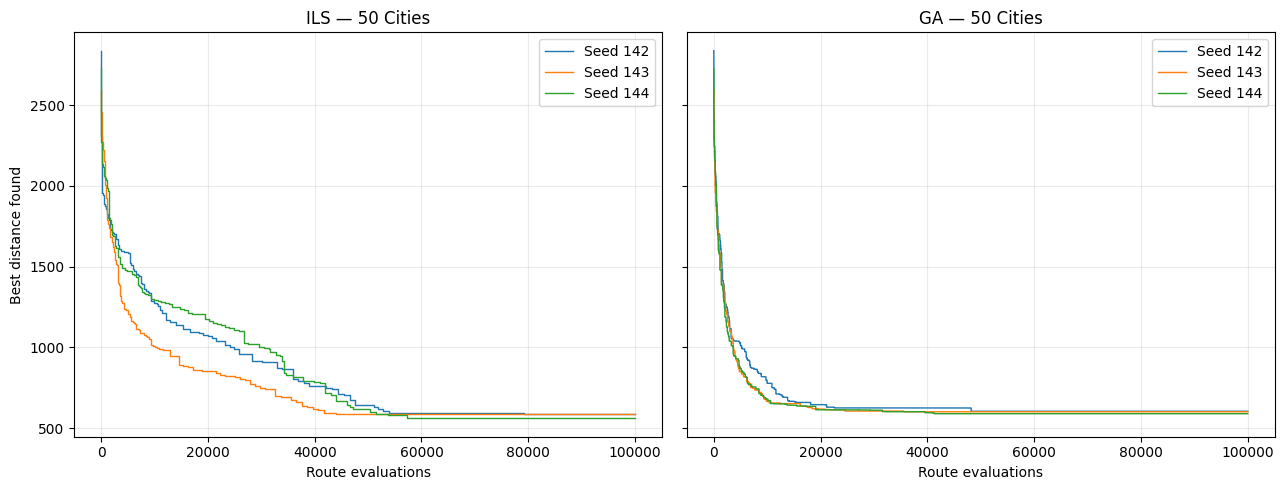

In [49]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(13, 5),
    sharex=True,
    sharey=True
)

for ax, name in zip(axes, ["ILS", "GA"]):
    for seed in PILOT_SEEDS:
        result = pilot_results[(name, seed)]
        counts, distances = zip(*result["history"])

        ax.step(
            counts,
            distances,
            where="post",
            label=f"Seed {seed}",
            linewidth=1
        )

    ax.set_title(f"{name} — 50 Cities")
    ax.set_xlabel("Route evaluations")
    ax.grid(alpha=0.25)
    ax.legend()

axes[0].set_ylabel("Best distance found")
plt.tight_layout()
plt.show()

In [50]:
initial_search_rows = []

for seed in PILOT_SEEDS:
    route = generate_random_route(50, seed)

    _, distance, used, _ = two_opt_local_search(
        route,
        pilot_matrix,
        max_evaluations=PILOT_MAX_EVALUATIONS
    )

    initial_search_rows.append({
        "Seed": seed,
        "Initial 2-opt evaluations": used,
        "Initial 2-opt distance": distance,
        "Budget remaining for ILS": PILOT_MAX_EVALUATIONS - used
    })

display(pd.DataFrame(initial_search_rows))

,Seed,Initial 2-opt evaluations,Initial 2-opt distance,Budget remaining for ILS
0,142,55118,595.589600,44882
1,143,45118,585.296886,54882
2,144,59559,559.864656,40441


In [51]:
from pathlib import Path
from datetime import datetime, timezone
import gzip
import json
import platform

EXPERIMENT_SEEDS = list(range(42, 52))
EXPERIMENT_SIZES = [10, 20, 30, 40, 50]
EVALUATION_BUDGET = 100_000

GA_SETTINGS = {
    "population_size": 50,
    "mutation_rate": 0.2,
    "tournament_size": 3
}

# Give this experiment its own output folder.
run_stamp = datetime.now(timezone.utc).strftime(
    "%Y%m%d_%H%M%S_%f"
)

experiment_dir = Path("Results") / f"experiment_{run_stamp}"
history_dir = experiment_dir / "histories"

history_dir.mkdir(parents=True, exist_ok=True)

settings = {
    "problem_sizes": EXPERIMENT_SIZES,
    "seeds": EXPERIMENT_SEEDS,
    "evaluation_budget": EVALUATION_BUDGET,
    "city_selection": "First n rows in the original dataset order",
    "distance_measure": "Unrounded Euclidean distance",
    "ILS": {
        "local_search": "First-improvement 2-opt",
        "perturbation": "Two disjoint swaps, starting city fixed",
        "acceptance": "Strict improvement"
    },
    "GA": GA_SETTINGS,
    "python_version": platform.python_version(),
    "numpy_version": np.__version__,
    "pandas_version": pd.__version__
}

with open(experiment_dir / "settings.json", "w") as file:
    json.dump(settings, file, indent=2)

# Preserve the exact city data used for this experiment.
cities_df.to_csv(experiment_dir / "cities_used.csv", index=False)

print("Output folder:", experiment_dir.resolve())
print("Total planned runs:", 100)

Output folder: C:\Users\yasee\OneDrive - UWE Bristol\Desktop\AI-for-Search-and-Optimisation\Results\experiment_20260915_113404_325433
Total planned runs: 100


In [52]:
experiment_rows = []
completed = 0

total_runs = (
    len(EXPERIMENT_SIZES)
    * len(EXPERIMENT_SEEDS)
    * 2
)

for size_index, city_count in enumerate(EXPERIMENT_SIZES):
    matrix = distance_matrix[:city_count, :city_count]

    for seed_index, seed in enumerate(EXPERIMENT_SEEDS):
        algorithm_order = ["ILS", "GA"]

        # Balance which algorithm runs first.
        if (size_index + seed_index) % 2 == 1:
            algorithm_order.reverse()

        for name in algorithm_order:
            start_time = time.perf_counter()

            if name == "ILS":
                result = iterated_local_search_budgeted(
                    matrix=matrix,
                    seed=seed,
                    max_evaluations=EVALUATION_BUDGET
                )
            else:
                result = genetic_algorithm(
                    matrix=matrix,
                    seed=seed,
                    max_evaluations=EVALUATION_BUDGET,
                    **GA_SETTINGS
                )

            runtime = time.perf_counter() - start_time

            # Validation happens outside the timed search.
            assert result["evaluations"] == EVALUATION_BUDGET

            assert sorted(result["route"]) == list(
                range(city_count)
            )

            assert np.isclose(
                result["distance"],
                calculate_route_distance(result["route"], matrix)
            )

            assert (
                result["history"][-1][0]
                == EVALUATION_BUDGET
            )

            # Save this run, including its convergence history.
            history_name = (
                f"{name}_{city_count}_cities_seed_{seed}.json.gz"
            )

            with gzip.open(
                history_dir / history_name,
                "wt",
                encoding="utf-8"
            ) as file:
                json.dump(result, file)

            experiment_rows.append({
                "Algorithm": name,
                "City count": city_count,
                "Seed": seed,
                "Best distance": result["distance"],
                "Runtime": runtime,
                "Number of evaluations": result["evaluations"],
                "Final route": json.dumps(result["route"]),
                "History file": f"histories/{history_name}"
            })

            # Update the results after every completed run.
            results_df = pd.DataFrame(experiment_rows)

            results_df.to_csv(
                experiment_dir / "results.csv",
                index=False
            )

            completed += 1

            print(
                f"[{completed}/{total_runs}] "
                f"{name} | cities={city_count} | seed={seed} | "
                f"distance={result['distance']:.2f} | "
                f"time={runtime:.2f}s",
                flush=True
            )

print("All experiments completed.")

[1/100] ILS | cities=10 | seed=42 | distance=290.31 | time=0.89s
[2/100] GA | cities=10 | seed=42 | distance=290.31 | time=11.18s
[3/100] GA | cities=10 | seed=43 | distance=290.31 | time=8.50s
[4/100] ILS | cities=10 | seed=43 | distance=290.31 | time=0.90s
[5/100] ILS | cities=10 | seed=44 | distance=290.31 | time=1.11s
[6/100] GA | cities=10 | seed=44 | distance=290.31 | time=8.74s
[7/100] GA | cities=10 | seed=45 | distance=290.31 | time=7.90s
[8/100] ILS | cities=10 | seed=45 | distance=290.31 | time=0.70s
[9/100] ILS | cities=10 | seed=46 | distance=290.31 | time=0.93s
[10/100] GA | cities=10 | seed=46 | distance=290.31 | time=10.78s
[11/100] GA | cities=10 | seed=47 | distance=290.31 | time=12.04s
[12/100] ILS | cities=10 | seed=47 | distance=290.31 | time=0.94s
[13/100] ILS | cities=10 | seed=48 | distance=290.31 | time=1.91s
[14/100] GA | cities=10 | seed=48 | distance=290.31 | time=13.43s
[15/100] GA | cities=10 | seed=49 | distance=290.31 | time=9.65s
[16/100] ILS | cities=1

In [53]:
expected_runs = {
    (algorithm, city_count, seed)
    for algorithm in ["ILS", "GA"]
    for city_count in EXPERIMENT_SIZES
    for seed in EXPERIMENT_SEEDS
}

actual_runs = set(
    results_df[
        ["Algorithm", "City count", "Seed"]
    ].itertuples(index=False, name=None)
)

assert len(results_df) == 100
assert actual_runs == expected_runs

assert not results_df.duplicated(
    ["Algorithm", "City count", "Seed"]
).any()

assert results_df["Number of evaluations"].eq(
    EVALUATION_BUDGET
).all()

assert np.isfinite(
    results_df[["Best distance", "Runtime"]].to_numpy()
).all()

assert results_df["Runtime"].gt(0).all()

print("Verified: 100 unique runs with the correct budgets.")

display(
    results_df.groupby(
        ["City count", "Algorithm"]
    ).size().unstack("Algorithm")
)

Verified: 100 unique runs with the correct budgets.


Algorithm,GA,ILS
City count,,
10,10,10
20,10,10
30,10,10
40,10,10
50,10,10


In [70]:
summary_df = (
    results_df
    .groupby(["City count", "Algorithm"])
    .agg(
        Runs=("Seed", "count"),
        Evaluations_min=("Number of evaluations", "min"),
        Evaluations_max=("Number of evaluations", "max"),
        Best=("Best distance", "min"),
        Worst=("Best distance", "max"),
        Mean=("Best distance", "mean"),
        Median=("Best distance", "median"),
        Distance_SD=("Best distance", "std"),
        Runtime_mean=("Runtime", "mean"),
        Runtime_SD=("Runtime", "std")
    )
    .reset_index()
)

assert summary_df["Evaluations_min"].eq(100_000).all()
assert summary_df["Evaluations_max"].eq(100_000).all()

display(summary_df.round(4))

summary_df.to_csv(
    experiment_dir / "summary_statistics.csv",
    index=False
)

,City count,Algorithm,Runs,Evaluations_min,Evaluations_max,Best,Worst,Mean,Median,Distance_SD,Runtime_mean,Runtime_SD
0,10,GA,10,100000,100000,290.3068,290.3068,290.3068,290.3068,0.0000,10.3333,1.6994
1,10,ILS,10,100000,100000,290.3068,290.3068,290.3068,290.3068,0.0000,1.0805,0.4471
2,20,GA,10,100000,100000,386.4297,438.1616,391.7211,386.6267,16.3178,13.9292,2.4050
3,20,ILS,10,100000,100000,386.4297,386.4297,386.4297,386.4297,0.0000,2.6695,0.8781
4,30,GA,10,100000,100000,451.7670,483.3354,459.1461,459.2325,9.3113,14.7764,1.2412
5,30,ILS,10,100000,100000,451.7670,451.7670,451.7670,451.7670,0.0000,3.3916,0.5306
6,40,GA,10,100000,100000,489.7316,564.6134,523.8433,518.3552,28.1426,14.9860,1.5320
7,40,ILS,10,100000,100000,489.7316,521.1483,500.2963,495.7426,11.7493,3.5851,0.3414
8,50,GA,10,100000,100000,576.7547,629.6636,594.5714,590.4933,15.9884,15.3578,1.0307
9,50,ILS,10,100000,100000,564.1348,599.1051,579.7012,580.7421,9.1581,4.1979,0.2891


In [55]:
distance_comparison = summary_df.pivot(
    index="City count",
    columns="Algorithm",
    values="Mean"
).copy()

distance_comparison.columns.name = None

distance_comparison["GA minus ILS"] = (
    distance_comparison["GA"] - distance_comparison["ILS"]
)

distance_comparison["ILS reduction vs GA (%)"] = (
    (distance_comparison["GA"] - distance_comparison["ILS"])
    / distance_comparison["GA"]
    * 100
)

display(distance_comparison.round(4))

,GA,ILS,GA minus ILS,ILS reduction vs GA (%)
City count,,,,
10,290.3068,290.3068,0.0000,0.0000
20,391.7211,386.4297,5.2914,1.3508
30,459.1461,451.7670,7.3791,1.6071
40,523.8433,500.2963,23.5469,4.4950
50,594.5714,579.7012,14.8702,2.5010


In [56]:
runtime_comparison = summary_df.pivot(
    index="City count",
    columns="Algorithm",
    values="Runtime_mean"
).copy()

runtime_comparison.columns.name = None

runtime_comparison["GA / ILS runtime ratio"] = (
    runtime_comparison["GA"] / runtime_comparison["ILS"]
)

display(runtime_comparison.round(3))

,GA,ILS,GA / ILS runtime ratio
City count,,,
10,10.333,1.081,9.563
20,13.929,2.669,5.218
30,14.776,3.392,4.357
40,14.986,3.585,4.180
50,15.358,4.198,3.658


In [57]:
summary_df.to_csv(
    experiment_dir / "summary_statistics.csv",
    index=False
)

distance_comparison.to_csv(
    experiment_dir / "distance_comparison.csv"
)

runtime_comparison.to_csv(
    experiment_dir / "runtime_comparison.csv"
)

print("Summary tables saved.")

Summary tables saved.


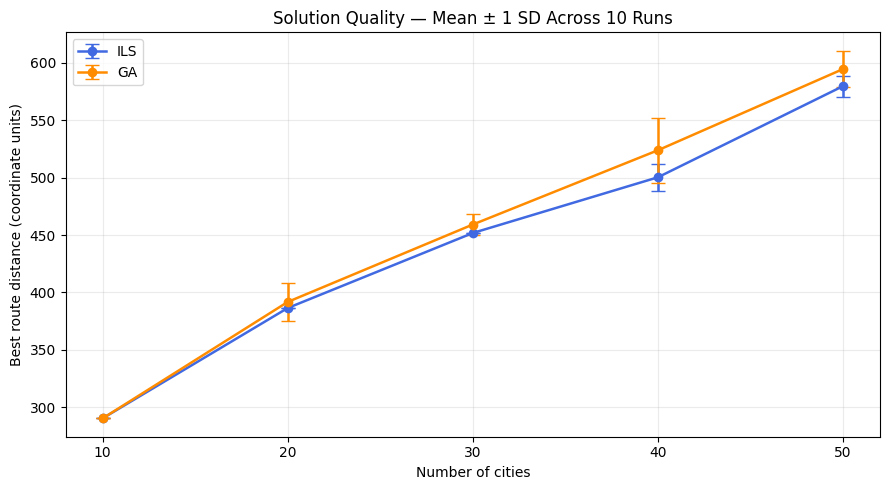

In [58]:
figures_dir = experiment_dir / "figures"
figures_dir.mkdir(exist_ok=True)

algorithm_colors = {
    "ILS": "royalblue",
    "GA": "darkorange"
}

fig, ax = plt.subplots(figsize=(9, 5))

for name in ["ILS", "GA"]:
    data = (
        summary_df[summary_df["Algorithm"] == name]
        .sort_values("City count")
    )

    ax.errorbar(
        data["City count"],
        data["Mean"],
        yerr=data["Distance_SD"],
        label=name,
        color=algorithm_colors[name],
        marker="o",
        capsize=5,
        linewidth=1.8
    )

ax.set_title("Solution Quality — Mean ± 1 SD Across 10 Runs")
ax.set_xlabel("Number of cities")
ax.set_ylabel("Best route distance (coordinate units)")
ax.set_xticks(EXPERIMENT_SIZES)
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
fig.savefig(figures_dir / "mean_distance_vs_cities.png", dpi=300)
fig.savefig(figures_dir / "mean_distance_vs_cities.pdf")
plt.show()

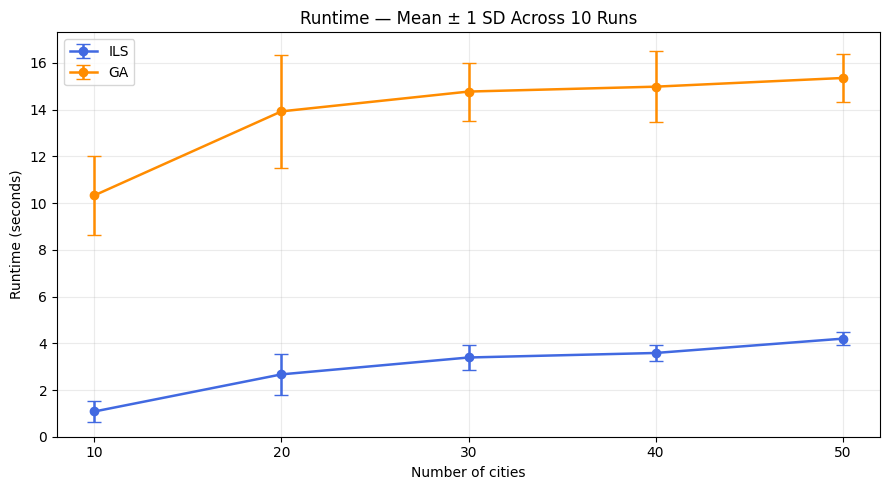

In [59]:
fig, ax = plt.subplots(figsize=(9, 5))

for name in ["ILS", "GA"]:
    data = (
        summary_df[summary_df["Algorithm"] == name]
        .sort_values("City count")
    )

    ax.errorbar(
        data["City count"],
        data["Runtime_mean"],
        yerr=data["Runtime_SD"],
        label=name,
        color=algorithm_colors[name],
        marker="o",
        capsize=5,
        linewidth=1.8
    )

ax.set_title("Runtime — Mean ± 1 SD Across 10 Runs")
ax.set_xlabel("Number of cities")
ax.set_ylabel("Runtime (seconds)")
ax.set_xticks(EXPERIMENT_SIZES)
ax.set_ylim(bottom=0)
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
fig.savefig(figures_dir / "runtime_vs_cities.png", dpi=300)
fig.savefig(figures_dir / "runtime_vs_cities.pdf")
plt.show()

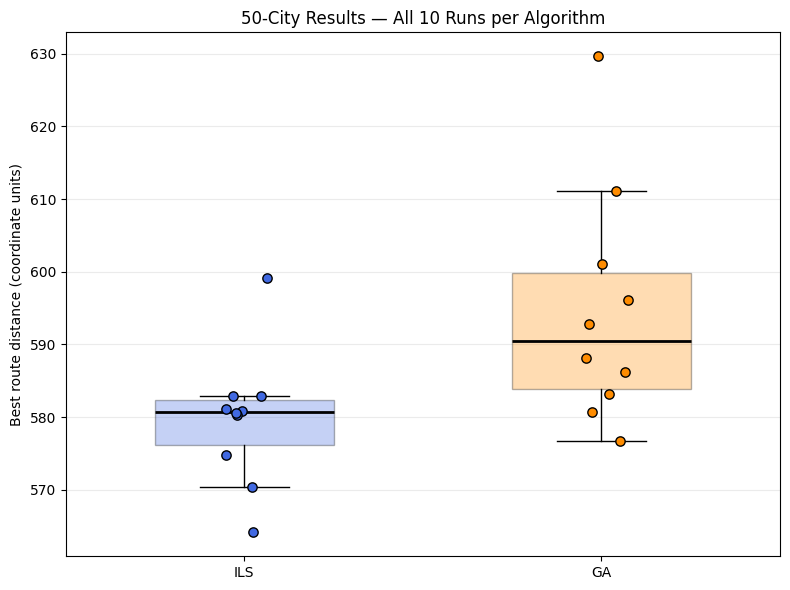

In [60]:
algorithm_order = ["ILS", "GA"]

distances_50 = [
    results_df.loc[
        (results_df["City count"] == 50)
        & (results_df["Algorithm"] == name),
        "Best distance"
    ].to_numpy()
    for name in algorithm_order
]

assert all(len(values) == 10 for values in distances_50)

fig, ax = plt.subplots(figsize=(8, 6))

boxes = ax.boxplot(
    distances_50,
    positions=[1, 2],
    widths=0.5,
    patch_artist=True,
    showfliers=False,
    medianprops={"color": "black", "linewidth": 2}
)

# Separate generator used only for point placement.
plot_rng = np.random.default_rng(2026)

for position, name, values, box in zip(
    [1, 2],
    algorithm_order,
    distances_50,
    boxes["boxes"]
):
    box.set_facecolor(algorithm_colors[name])
    box.set_alpha(0.3)

    x_positions = (
        position + plot_rng.uniform(-0.08, 0.08, len(values))
    )

    ax.scatter(
        x_positions,
        values,
        color=algorithm_colors[name],
        edgecolor="black",
        s=45,
        zorder=3
    )

ax.set_xticks([1, 2])
ax.set_xticklabels(algorithm_order)
ax.set_title("50-City Results — All 10 Runs per Algorithm")
ax.set_ylabel("Best route distance (coordinate units)")
ax.grid(axis="y", alpha=0.25)

fig.tight_layout()
fig.savefig(figures_dir / "boxplot_50_cities.png", dpi=300)
fig.savefig(figures_dir / "boxplot_50_cities.pdf")
plt.show()

In [61]:
best_50_runs = {}
best_50_rows = []

for name in ["ILS", "GA"]:
    candidates = results_df[
        (results_df["Algorithm"] == name)
        & (results_df["City count"] == 50)
    ]

    best_row = candidates.sort_values(
        ["Best distance", "Seed"]
    ).iloc[0]

    history_path = experiment_dir / best_row["History file"]

    with gzip.open(history_path, "rt", encoding="utf-8") as file:
        saved_run = json.load(file)

    assert sorted(saved_run["route"]) == list(range(50))

    assert np.isclose(
        saved_run["distance"],
        calculate_route_distance(
            saved_run["route"],
            distance_matrix[:50, :50]
        )
    )

    assert np.isclose(
        saved_run["distance"],
        best_row["Best distance"]
    )

    best_50_runs[name] = saved_run

    best_50_rows.append({
        "Algorithm": name,
        "Seed": int(best_row["Seed"]),
        "Best distance": saved_run["distance"]
    })

best_50_df = pd.DataFrame(best_50_rows)
display(best_50_df.round(4))

,Algorithm,Seed,Best distance
0,ILS,50,564.1348
1,GA,47,576.7547


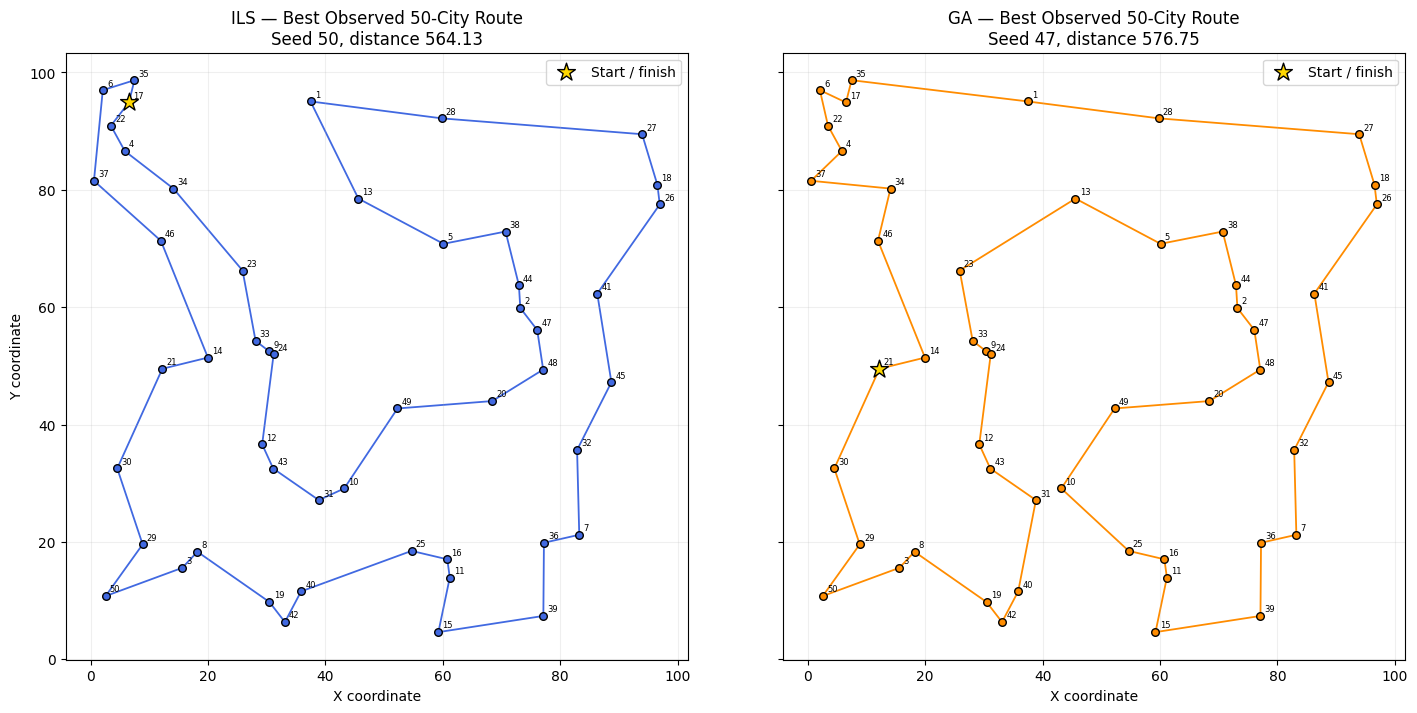

In [62]:
fig, axes = plt.subplots(
    1, 2,
    figsize=(15, 7),
    sharex=True,
    sharey=True
)

for ax, name in zip(axes, ["ILS", "GA"]):
    result = best_50_runs[name]
    route = result["route"]
    closed_route = route + [route[0]]

    route_coords = coordinates[closed_route]

    seed = int(
        best_50_df.loc[
            best_50_df["Algorithm"] == name, "Seed"
        ].iloc[0]
    )

    ax.plot(
        route_coords[:, 0],
        route_coords[:, 1],
        color=algorithm_colors[name],
        linewidth=1.3,
        zorder=1
    )

    ax.scatter(
        coordinates[:50, 0],
        coordinates[:50, 1],
        color=algorithm_colors[name],
        edgecolor="black",
        s=30,
        zorder=2
    )

    for index in range(50):
        ax.annotate(
            str(city_names[index]).replace("City_", ""),
            coordinates[index],
            xytext=(3, 3),
            textcoords="offset points",
            fontsize=6
        )

    start = route[0]

    ax.scatter(
        coordinates[start, 0],
        coordinates[start, 1],
        marker="*",
        color="gold",
        edgecolor="black",
        s=180,
        label="Start / finish",
        zorder=3
    )

    ax.set_title(
        f"{name} — Best Observed 50-City Route\n"
        f"Seed {seed}, distance {result['distance']:.2f}"
    )

    ax.set_xlabel("X coordinate")
    ax.set_aspect("equal", adjustable="box")
    ax.grid(alpha=0.2)
    ax.legend()

axes[0].set_ylabel("Y coordinate")

fig.tight_layout()
fig.savefig(figures_dir / "best_routes_50_cities.png", dpi=300)
fig.savefig(figures_dir / "best_routes_50_cities.pdf")
plt.show()

In [63]:
evaluation_grid = np.linspace(
    1,
    EVALUATION_BUDGET,
    501,
    dtype=int
)

convergence_50 = {}

for name in ["ILS", "GA"]:
    run_rows = results_df[
        (results_df["Algorithm"] == name)
        & (results_df["City count"] == 50)
    ].sort_values("Seed")

    aligned_histories = []

    for _, row in run_rows.iterrows():
        with gzip.open(
            experiment_dir / row["History file"],
            "rt",
            encoding="utf-8"
        ) as file:
            saved_run = json.load(file)

        history = np.asarray(saved_run["history"], dtype=float)

        counts = history[:, 0]
        distances = history[:, 1]

        assert counts[0] == 1
        assert counts[-1] == EVALUATION_BUDGET
        assert np.all(np.diff(counts) >= 0)

        positions = np.searchsorted(
            counts,
            evaluation_grid,
            side="right"
        ) - 1

        aligned_histories.append(distances[positions])

    aligned_histories = np.vstack(aligned_histories)

    assert aligned_histories.shape == (10, len(evaluation_grid))

    convergence_50[name] = {
        "mean": aligned_histories.mean(axis=0),
        "sd": aligned_histories.std(axis=0, ddof=1)
    }

    expected_mean = summary_df.loc[
        (summary_df["Algorithm"] == name)
        & (summary_df["City count"] == 50),
        "Mean"
    ].iloc[0]

    assert np.isclose(
        convergence_50[name]["mean"][-1],
        expected_mean
    )

print("Convergence histories aligned and final means verified.")

Convergence histories aligned and final means verified.


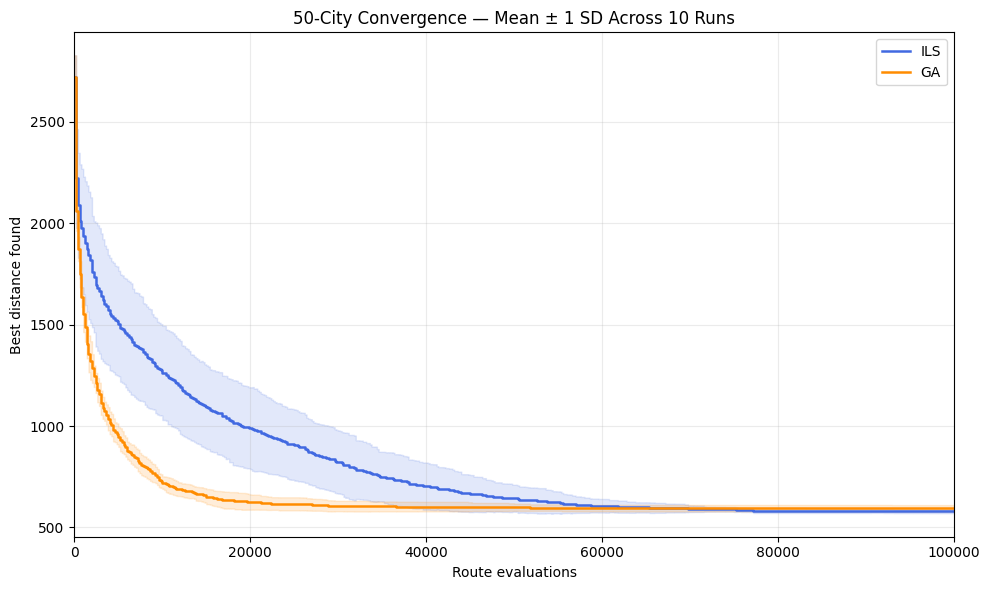

In [64]:
fig, ax = plt.subplots(figsize=(10, 6))

for name in ["ILS", "GA"]:
    mean = convergence_50[name]["mean"]
    sd = convergence_50[name]["sd"]
    color = algorithm_colors[name]

    ax.step(
        evaluation_grid,
        mean,
        where="post",
        color=color,
        label=name,
        linewidth=1.8
    )

    ax.fill_between(
        evaluation_grid,
        mean - sd,
        mean + sd,
        step="post",
        color=color,
        alpha=0.15
    )

ax.set_title("50-City Convergence — Mean ± 1 SD Across 10 Runs")
ax.set_xlabel("Route evaluations")
ax.set_ylabel("Best distance found")
ax.set_xlim(0, EVALUATION_BUDGET)
ax.grid(alpha=0.25)
ax.legend()

fig.tight_layout()
fig.savefig(figures_dir / "mean_convergence_50_cities.png", dpi=300)
fig.savefig(figures_dir / "mean_convergence_50_cities.pdf")
plt.show()

In [65]:
ALPHA = 0.05
TEST_DECIMALS = 9


def welch_test(x, y):
    # Explicitly recognise constant samples.
    sd_x = 0.0 if np.ptp(x) == 0 else x.std(ddof=1)
    sd_y = 0.0 if np.ptp(y) == 0 else y.std(ddof=1)

    if sd_x == 0 and sd_y == 0:
        return np.nan, np.nan

    result = stats.ttest_ind_from_stats(
        mean1=x.mean(),
        std1=sd_x,
        nobs1=len(x),
        mean2=y.mean(),
        std2=sd_y,
        nobs2=len(y),
        equal_var=False,
        alternative="two-sided"
    )

    return float(result.statistic), float(result.pvalue)


def mean_difference(x, y):
    return np.mean(x) - np.mean(y)


def holm_adjust(p_values):
    p_values = np.asarray(p_values, dtype=float)
    missing = np.isnan(p_values)

    # Keep undefined tests in the planned family conservatively.
    working = np.where(missing, 1.0, p_values)

    order = np.argsort(working)
    m = len(working)

    adjusted_sorted = np.minimum(
        1.0,
        np.maximum.accumulate(
            working[order] * np.arange(m, 0, -1)
        )
    )

    adjusted = np.empty(m)
    adjusted[order] = adjusted_sorted
    adjusted[missing] = np.nan

    return adjusted

In [66]:
test_rows = []

for city_count in EXPERIMENT_SIZES:
    paired = (
        results_df[results_df["City count"] == city_count]
        .pivot(
            index="Seed",
            columns="Algorithm",
            values="Best distance"
        )
        .sort_index()
    )

    assert list(paired.index) == EXPERIMENT_SEEDS
    assert not paired[["ILS", "GA"]].isna().any().any()

    ils = np.round(
        paired["ILS"].to_numpy(), TEST_DECIMALS
    )
    ga = np.round(
        paired["GA"].to_numpy(), TEST_DECIMALS
    )

    t_statistic, t_p = welch_test(ils, ga)

    u_result = stats.mannwhitneyu(
        ils,
        ga,
        alternative="two-sided",
        method="asymptotic",
        use_continuity=True
    )

    paired_result = stats.permutation_test(
        (ils, ga),
        statistic=mean_difference,
        permutation_type="samples",
        vectorized=False,
        n_resamples=np.inf,
        alternative="two-sided"
    )

    tests = [
        ("Welch", t_statistic, t_p),
        (
            "Mann-Whitney",
            float(u_result.statistic),
            float(u_result.pvalue)
        ),
        (
            "Paired permutation",
            float(paired_result.statistic),
            float(paired_result.pvalue)
        )
    ]

    for test_name, statistic, p_value in tests:
        test_rows.append({
            "City count": city_count,
            "Test": test_name,
            "Mean difference (ILS - GA)": float(
                ils.mean() - ga.mean()
            ),
            "Statistic": statistic,
            "p_raw": p_value
        })

tests_df = pd.DataFrame(test_rows)

In [67]:
tests_df["p_holm"] = holm_adjust(tests_df["p_raw"])

tests_df["Decision"] = tests_df["p_holm"].apply(
    lambda p: (
        "Undefined"
        if pd.isna(p)
        else (
            "Reject null"
            if p < ALPHA
            else "Do not reject null"
        )
    )
)

display(
    tests_df.style.format({
        "Mean difference (ILS - GA)": "{:.4f}",
        "Statistic": "{:.4f}",
        "p_raw": "{:.6g}",
        "p_holm": "{:.6g}"
    }, na_rep="N/A")
)

,City count,Test,Mean difference (ILS - GA),Statistic,p_raw,p_holm,Decision
0,10,Welch,0.0000,N/A,N/A,N/A,Undefined
1,10,Mann-Whitney,0.0000,50.0000,1,1,Do not reject null
2,10,Paired permutation,0.0000,0.0000,1,1,Do not reject null
3,20,Welch,-5.2914,-1.0254,0.331929,1,Do not reject null
4,20,Mann-Whitney,-5.2914,15.0000,0.00182638,0.0273957,Reject null
5,20,Paired permutation,-5.2914,-5.2914,0.015625,0.171875,Do not reject null
6,30,Welch,-7.3791,-2.5061,0.0335264,0.247975,Do not reject null
7,30,Mann-Whitney,-7.3791,15.0000,0.00216604,0.0303246,Reject null
8,30,Paired permutation,-7.3791,-7.3791,0.015625,0.171875,Do not reject null
9,40,Welch,-23.5469,-2.4416,0.0309969,0.247975,Do not reject null


In [68]:
tests_df.to_csv(
    experiment_dir / "statistical_tests.csv",
    index=False
)

statistical_settings = {
    "outcome": "Final best route distance",
    "alternative": "Two-sided",
    "alpha": ALPHA,
    "test_decimal_places": TEST_DECIMALS,
    "multiple_comparison_correction": "Holm",
    "planned_comparisons": 15,
    "mann_whitney_method": "Asymptotic with tie correction",
    "paired_permutation": "Exact within-seed label swaps",
    "undefined_welch": "Both samples have zero variance"
}

with open(
    experiment_dir / "statistical_settings.json", "w"
) as file:
    json.dump(statistical_settings, file, indent=2)

print("Statistical results saved.")

Statistical results saved.


In [71]:
statistical_overview = tests_df.pivot(
    index="City count",
    columns="Test",
    values="p_holm"
)

statistical_overview = statistical_overview[
    ["Welch", "Mann-Whitney", "Paired permutation"]
]

display(
    statistical_overview.style.format(
        "{:.4f}",
        na_rep="Undefined"
    )
)

Test,Welch,Mann-Whitney,Paired permutation
City count,,,
10,Undefined,1.0000,1.0000
20,1.0000,0.0274,0.1719
30,0.2480,0.0303,0.1719
40,0.2480,0.3466,0.2578
50,0.2043,0.1682,0.1270


Values below 0.05 indicate rejection of the corresponding null hypothesis after Holm correction. Only the Mann–Whitney comparisons at 20 and 30 cities meet this threshold. No Welch or paired permutation comparison rejects its null hypothesis. The 10-city Welch test is undefined because both samples have zero variation.

The independent-sample tests remain exploratory because the algorithms reused seeds. The paired permutation sensitivity analysis preserves seed pairing but still relies on exchangeability under its null hypothesis. These results do not establish a consistent advantage across tests.


## Discussion

The experiment compared Iterated Local Search (ILS) and a Genetic Algorithm (GA) on five fixed Travelling Salesman Problem instances containing 10–50 cities. Each algorithm received 100,000 route evaluations per run and was repeated using ten seeds.

Both algorithms achieved the same distance on the 10-city instance. ILS produced lower mean distances on the remaining instances, with reductions relative to GA of 1.35%, 1.61%, 4.50%, and 2.50% for 20, 30, 40, and 50 cities respectively. ILS also showed lower variation across seeds on these instances. Repeatedly finding the same distance at smaller sizes indicates consistency, but does not prove global optimality.

The convergence results reveal a trade-off. On the 50-city instance, GA improved more quickly during the early evaluation budget, whereas ILS improved more gradually and achieved a lower final mean distance. The relative performance therefore depended on when the search was stopped.

ILS had lower measured mean runtime at every problem size. GA took approximately 3.66–9.56 times longer on average. Although both algorithms used the same number of complete route evaluations, their additional operations differed. These timings describe the implementations and execution environment used in this experiment.

After Holm correction across 15 comparisons, the Mann–Whitney tests rejected their null hypotheses at 20 and 30 cities, with adjusted p-values of 0.0274 and 0.0303. No Welch or paired permutation comparison rejected its null hypothesis. The Mann–Whitney findings are exploratory because the samples reused seeds and the p-values used an asymptotic approximation with ties. Overall, the descriptive results favour ILS, while the inferential evidence is limited and depends on the test used.


## Limitations
Several limitations restrict the conclusions:

* Each problem size used one fixed subset of the same dataset. Repeated seeds measure algorithm variability on those instances, not performance across a broad collection of TSP instances.
* Ten runs per algorithm and size provide limited information about the result distributions, particularly when distances contain many ties or occasional poor runs.
* Seeds were reused across algorithms, creating shared initial randomness. The paired permutation analysis addresses seed pairing but still relies on exchangeability under its null hypothesis.
* The evaluation budget and algorithm configurations influence the comparison. The pilot demonstrated that the relative ranking could change with the budget. Neither algorithm received extensive parameter tuning.
* Equal evaluation counts do not guarantee equal computational effort. Runtime also depends on implementation details, hardware, and background system activity.
* No exact solver or certified optimum was used. Consequently, the study reports best observed distances rather than optimality gaps.

Future work could use more independent problem instances and runs, examine several evaluation and time budgets, and compare results against exact solutions where feasible.


## Conclusion
Under the tested configurations and a budget of 100,000 route evaluations, ILS matched GA’s mean solution quality at 10 cities and produced lower mean distances at 20–50 cities. It also showed greater consistency on the larger instances and lower measured runtime at every size.

GA improved more quickly early in the 50-city search, while ILS achieved a better final mean distance. This demonstrates that convergence behaviour and the available search budget matter alongside final solution quality.

The results favour this ILS implementation for the tested instances and budget. However, the adjusted statistical comparisons do not establish a consistent difference across tests, and the limited instance set prevents a general claim that ILS is superior to GA for the TSP.


## References

* Croes, G. A. (1958). [A Method for Solving Traveling-Salesman Problems](https://pubsonline.informs.org/doi/10.1287/opre.6.6.791). *Operations Research*, 6(6), 791–812.

* Lourenço, H. R., Martin, O. C. and Stützle, T. (2001). [Iterated Local Search](https://arxiv.org/abs/math/0102188). arXiv:math/0102188.
* SciPy documentation. [Welch’s t-test from descriptive statistics](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.ttest_ind_from_stats.html).
* SciPy documentation. [Mann–Whitney U test](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.mannwhitneyu.html).
* SciPy documentation. [Permutation tests](https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.permutation_test.html).
* Statsmodels documentation. [Multiple-testing corrections, including Holm](https://www.statsmodels.org/v0.11.1/generated/statsmodels.stats.multitest.multipletests.html).
Holland, J. H. (1992). *Adaptation in Natural and Artificial Systems*. MIT Press. https://mitpress.mit.edu/9780262581110/adaptation-in-natural-and-artificial-systems/
